In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import matplotlib
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import figures
from figures import style
matplotlib.rcParams.update(**style['rcparams'])

import src as src
from src.reload import deep_reload

In [7]:
trips = src.graph.graph_from_json('Data/Unitrans/trips.json')

locations = src.graph.graph_from_json('Data/Unitrans/locations.json')

In [15]:
'''
Adding "Home" Depots
'''
depots = [k for k, v in locations._node.items() if v['type'] == 'depot']

depot_assignment = {
    vi: k for k, v in nx.voronoi_cells(
        locations, depots, weight = 'distance').items() for vi in list(v)
}

for k, v in locations._node.items():

    v['depot'] = depot_assignment[k]

for k, v in trips._node.items():

    v['depots'] = [
        locations._node[v['start_location']]['depot'],
        ]

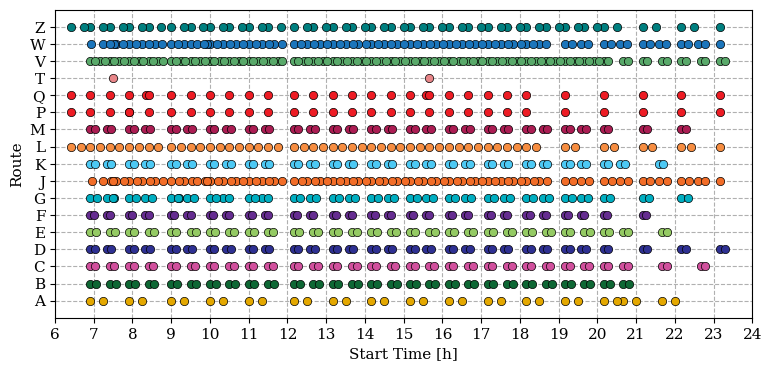

In [10]:
'''
Plot Unitrans Scehdule
'''

routes_df = pd.read_csv('Data/Unitrans_GTFS/routes.txt')
routes = {row['route_id']: row.to_dict() for idx, row in routes_df.iterrows()}

fig, ax = plt.subplots(figsize = (9, 4))

ticks = []
labels = []

k = 0

for idx, (route, data) in enumerate(routes.items()):

    if not type(data['route_color']) is str:
        continue

    x = np.array(
        [t['start'] for t in trips._node.values() if t['route'] == route]
    )
    y = np.array(
        [k for t in trips._node.values() if t['route'] == route]
    )

    if len(x) <= 1:

        continue

    _ = ax.scatter(
        x / 3600, y, c = '#' + data['route_color'].replace(' ' , ''),
        zorder = 4, ec = 'k', lw = .5
    )

    ticks.append(k)
    labels.append(route)

    k += 1

kw = {
    'xlabel': 'Start Time [h]',
    'ylabel': 'Route',
    'xlim': (6, 24),
    'ylim': (min(ticks) - 1, max(ticks) + 1),
    'xticks': list(range(6, 25, 1)),
    'yticks': ticks,
    'yticklabels': labels,
}

_ = ax.set(**kw)

_ = ax.grid(ls = '--')

In [11]:
deep_reload(src)

vehicles_data = json.load(open('Data/vehicle_types_reduced.json', 'r'))

vehicle_types = {
    v['type']: src.optimization.Vehicle_Type(**v) for v in vehicles_data
}

In [12]:
deep_reload(src)

ports_data = json.load(open('Data/port_types_reduced.json', 'r'))

port_types = {
    v['type']: src.optimization.Port_Type(**v) for v in ports_data
}

In [16]:
'''
Making a Network
'''
deep_reload(src)

objectives = {
    'Initial Cost': src.optimization.Initial_Cost(),
    'Daily Cost': src.optimization.Daily_Cost(),
}

constraints = {
    'Energy': src.optimization.Energy(),
    'Vehicle Fleet Size': src.optimization.Vehicle_Limit(
        sizes = {'Depot': 60},
        included = list(vehicle_types.keys())
    ),
    'Port Fleet Size': src.optimization.Port_Limit(
        sizes = {'Depot': 10},
        included = ['DC-PLUG', 'LH2-PUMP', 'DIESEL-PUMP'],
    ),
}


kw = {
    'trips': trips,
    'locations': locations,
    'vehicle_types': vehicle_types,
    'port_types': port_types,
    'constraints': constraints,
    'objectives': objectives,
}

network = src.optimization.Network(**kw)

In [17]:
'''
Running NSGA
'''
deep_reload(src)

rng = np.random.default_rng(1418165148741561)

n = 100
m = 100

kw = {
    'max_iter': n,
    'initial_population_size': m * 3,
    'population_size': m,
    'mutation_probability': 0.05,
    'crossover_probability': 0.5,
    'retries': 3,
}

population, generations = network.optimize(rng, **kw)

Generating Initial Population

 [-------------------->] 100.00%, 32.30 it/s, 9.35 s elapsed, 0.00 s remaining

Optimizing

 [------------------->] 100.00%, 1.31 s/it, 133.19 s elapsed, 0.00 s remaining


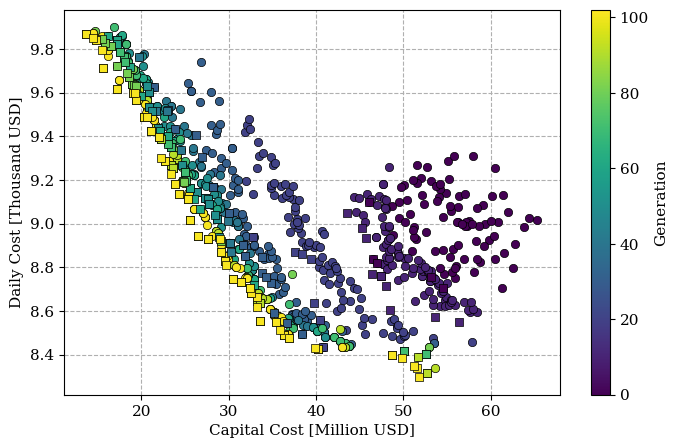

In [20]:
'''
Plotting generations
'''
deep_reload(src)
deep_reload(figures)

fig, ax = plt.subplots(figsize = (8, 5))

ax = figures.generations_plot(
    ax, generations, interval = 10, figsize = (6, 6), rank = 100
)

kw = {
    'xlabel': 'Capital Cost [Million USD]',
    'ylabel': 'Daily Cost [Thousand USD]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

cmap = src.plot.Colormap(vmin = 0, vmax = len(generations) + 1)
sm = matplotlib.cm.ScalarMappable(
    cmap = cmap.cmap, norm = cmap.norm
)

_ = plt.colorbar(sm, ax = ax, label = 'Generation')

In [21]:
population_dict = src.optimization.population_to_dict(population)

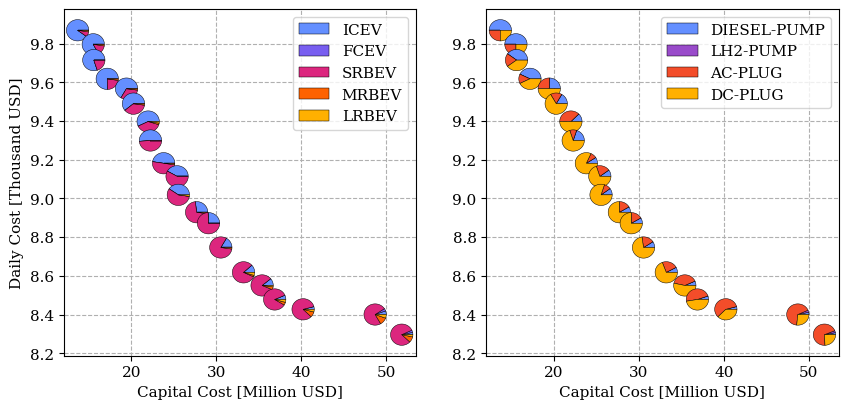

In [22]:
'''
Plotting Pareto Compositions
'''

deep_reload(src)
deep_reload(figures)

matplotlib.rcParams.update(**style['rcparams'])
fig, ax = plt.subplots(1, 2, figsize = (10, 4.5))

ax[0] = figures.vehicles_scatter_pie(
    ax[0], population_dict, n_shown = 20, size = .035,
    cmap = src.plot.Colormap('ibm'), exponent = 0,
    keys = ['ICEV', 'FCEV', 'SRBEV', 'MRBEV', 'LRBEV'],
)

ax[1] = figures.ports_scatter_pie(
    ax[1], population_dict, n_shown = 20, size = .035,
    cmap = src.plot.Colormap('ibm'), exponent = 0,
    keys = ['DIESEL-PUMP', 'LH2-PUMP', 'AC-PLUG', 'DC-PLUG'],
)

kw = {
    'xlabel': 'Capital Cost [Million USD]',
    'ylabel': 'Daily Cost [Thousand USD]',
}

_ = ax[0].set(**kw)

kw = {
    'xlabel': 'Capital Cost [Million USD]',
}

_ = ax[1].set(**kw)

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]
_ = [ax.legend() for ax in ax]

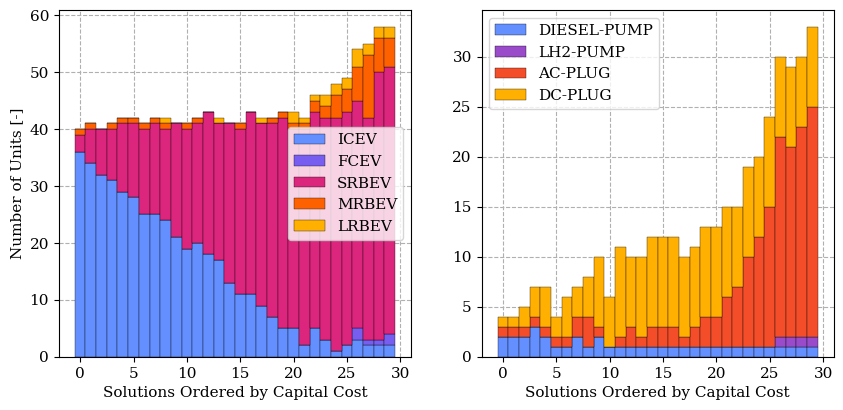

In [23]:
'''
Plotting Fleet Sizes and Compositions
'''
deep_reload(src)
deep_reload(figures)

matplotlib.rcParams.update(**style['rcparams'])
fig, ax = plt.subplots(1, 2, figsize = (10, 4.5))

ax[0] = figures.vehicles_stacked_bar(
    ax[0], population_dict, n_shown = 30, size = .035,
    cmap = src.plot.Colormap('ibm'),
    keys = ['ICEV', 'FCEV', 'SRBEV', 'MRBEV', 'LRBEV'],
)

ax[1] = figures.vehicles_ports_bar(
    ax[1], population_dict, n_shown = 30, size = .035,
    cmap = src.plot.Colormap('ibm'),
    keys = ['DIESEL-PUMP', 'LH2-PUMP', 'AC-PLUG', 'DC-PLUG'],
)

kw = {
    'ylabel': 'Number of Units [-]',
    'xlabel': 'Solutions Ordered by Capital Cost',
}

_ = ax[0].set(**kw)

kw = {
    'xlabel': 'Solutions Ordered by Capital Cost',
}

_ = ax[1].set(**kw)

kw = {
    'ls': '--',
    'zorder': 0,
}

_ = [ax.grid(**kw) for ax in ax]
_ = [ax.legend() for ax in ax]